# Ejercicio 1 — Cadenas de Markov y migración de ratings

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

---

## Objetivo

A partir de la matriz anual de transición de ratings:

1. calcular la probabilidad acumulada de default y la probabilidad de primer default en cada año hasta 25 años;
2. agregar esas probabilidades para la cohorte de 5.002 compañías;
3. obtener la distribución de rating a 25 años y comprobarla mediante simulación.

El recorrido es: una compañía con rating conocido → toda la cohorte → una compañía elegida al azar. Primero auditamos la matriz: sus filas deben sumar uno, no puede haber probabilidades negativas y Default debe ser absorbente.


## Configuración y auditoría del dato original

La tabla original de `matriz-ratings.xlsx`, hoja `Hoja1`, rango C3:J11, está incorporada a continuación con toda su precisión, sin normalizar ni redondear. Es el dato de entrada del enunciado, no un resultado calculado. Así este notebook se ejecuta por sí solo. La corrección de nueve filas a ocho estados se explica y aplica después, exactamente como en la resolución anterior.

Fuente original verificada (SHA-256): `eba5c1016fe9a17c25226a83cfe99e303a8801e6d1f21b814a44903b608289e3`.

**Ejecución:** Python 3, NumPy, pandas, Matplotlib y SciPy; Jupyter/IPython para visualizar. Reiniciar el kernel y ejecutar todas las celdas en orden. No se leen ni escriben archivos auxiliares. Las semillas están fijadas y las figuras quedan embebidas en el notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.prop_cycle": plt.cycler(color=["#001391", "#1973b8", "#5e9cc9"]),
    "axes.grid": True,
    "grid.alpha": 0.15,
    "axes.titleweight": "bold",
})

# Datos originales: Hoja1, C3:J11. Se conservan las nueve filas para auditar la corrección.
DESTINOS = ['Aaa', 'Aa', 'A', 'Baa', 'Ba', 'B', 'Caa-C', 'Default']
ORIGENES = ['Aaa', 'Aa', 'A', 'Baa', 'Ba', 'B', 'Caa', 'Ca-C', 'Default']
Q = np.array([[0.8239100651251718, 0.13353189584925174, 0.04232948754498213, 0.00022844851509747183,
  1.0296059180067391e-07, 4.904662003280946e-12, 3.8923065825545925e-16, 5.216254094999365e-22],
 [0.3261439389010661, 0.5813252907191696, 0.0767045849813816, 0.015798485602700266,
  2.7651626199185096e-05, 4.816050596528921e-08, 8.97705300116284e-12, 2.3113048019581464e-16],
 [0.01670233901954564, 0.17825992767066995, 0.5425594169905165, 0.24177087019767074,
  0.020648738470714852, 5.845799593872624e-05, 2.4964499830894063e-07, 9.94547807356765e-12],
 [4.955903539198899e-05, 0.009007525343366456, 0.3903044801016316, 0.34068829165801195,
  0.23608376114588217, 0.023824728922789515, 4.143846387062415e-05, 2.1532905563759428e-07],
 [1.0325416795298516e-07, 0.00014213536657130992, 0.014813253751496924, 0.09253187007368156,
  0.6335491653820795, 0.24603513875989436, 0.012803845953136628, 0.00012448745897170936],
 [1.5024787328214318e-11, 1.4168042336038897e-07, 0.00023401435205193583, 0.018384243568426096,
  0.1176141243159185, 0.3514420603106977, 0.5061264929118039, 0.006198922845653687],
 [2.3732355844881274e-16, 1.4570893836673915e-11, 1.5543813213964283e-07, 5.921875719675295e-05,
  0.005967324062938644, 0.12054538504051282, 0.5182276805050403, 0.3552002361816082],
 [4.762987257041718e-22, 5.958838180298093e-16, 2.742542709471328e-11, 1.0207430490953033e-07,
  0.00029039523825634866, 0.008363707269974246, 0.22867737777502256, 0.762668417615016],
 [0, 0, 0, 0, 0, 0, 0, 1]], dtype=float)

assert Q.shape == (9, 8)
assert np.all(np.isfinite(Q)) and np.all((Q >= 0) & (Q <= 1))
assert np.allclose(Q.sum(axis=1), 1.0, atol=5e-15, rtol=0)
assert np.array_equal(Q[-1], np.r_[np.zeros(7), 1.0])
print("Dato original incorporado: 9 orígenes × 8 destinos")
print(f"Máximo error de suma por fila: {np.max(np.abs(Q.sum(axis=1)-1)):.2e}")
print("Default es absorbente: sí")
display(pd.DataFrame(Q, index=ORIGENES, columns=DESTINOS))


Dato original incorporado: 9 orígenes × 8 destinos
Máximo error de suma por fila: 2.22e-16
Default es absorbente: sí


,Aaa,Aa,A,Baa,Ba,B,Caa-C,Default
Aaa,8.239101e-01,1.335319e-01,4.232949e-02,2.284485e-04,1.029606e-07,4.904662e-12,3.892307e-16,5.216254e-22
Aa,3.261439e-01,5.813253e-01,7.670458e-02,1.579849e-02,2.765163e-05,4.816051e-08,8.977053e-12,2.311305e-16
A,1.670234e-02,1.782599e-01,5.425594e-01,2.417709e-01,2.064874e-02,5.845800e-05,2.496450e-07,9.945478e-12
Baa,4.955904e-05,9.007525e-03,3.903045e-01,3.406883e-01,2.360838e-01,2.382473e-02,4.143846e-05,2.153291e-07
Ba,1.032542e-07,1.421354e-04,1.481325e-02,9.253187e-02,6.335492e-01,2.460351e-01,1.280385e-02,1.244875e-04
B,1.502479e-11,1.416804e-07,2.340144e-04,1.838424e-02,1.176141e-01,3.514421e-01,5.061265e-01,6.198923e-03
Caa,2.373236e-16,1.457089e-11,1.554381e-07,5.921876e-05,5.967324e-03,1.205454e-01,5.182277e-01,3.552002e-01
Ca-C,4.762987e-22,5.958838e-16,2.742543e-11,1.020743e-07,2.903952e-04,8.363707e-03,2.286774e-01,7.626684e-01
Default,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


## Corrección de la estructura de la matriz

**Decisión sobre el dato de entrada.** El fichero original presenta una inconsistencia de etiquetado entre filas y columnas. La resolvemos una sola vez siguiendo la convención documentada y, desde ese punto, trabajamos con una matriz de transición $P$ coherente de ocho estados. Los controles posteriores verifican que esta decisión se mantiene, pero no forman parte del razonamiento probabilístico principal.


El Excel contiene nueve filas de origen, porque desdobla el tramo inferior en `Caa` y `Ca-C`, pero solo ocho columnas de destino, donde ambos aparecen agregados como `Caa-C`. El enunciado también utiliza `Caa-C` como un único estado en la distribución inicial.

Siguiendo la aclaración de la profesora, se elimina la fila `Ca-C` y se conserva la fila `Caa` como representativa del estado agregado `Caa-C`. Esta elección se documenta expresamente y permite construir una matriz homogénea $P$ de dimensión $8\times8$. No se estiman ponderaciones que el enunciado no proporciona.


In [2]:
ESTADOS = DESTINOS
RATINGS = ESTADOS[:-1]

# Convención autorizada: se conserva la fila Caa (Q[6]) y se elimina Ca-C (Q[7]).
P = np.vstack([Q[:7], Q[8]])
assert P.shape == (8, 8)
assert np.all(P >= 0)
assert np.allclose(P.sum(axis=1), 1.0, atol=5e-15)
assert np.array_equal(P[-1], np.r_[np.zeros(7), 1.0])
assert np.array_equal(P[6], Q[6])

print("Matriz anual corregida: fila Caa asignada al estado Caa-C")
display(pd.DataFrame(P, index=ESTADOS, columns=ESTADOS))


Matriz anual corregida: fila Caa asignada al estado Caa-C


,Aaa,Aa,A,Baa,Ba,B,Caa-C,Default
Aaa,8.239101e-01,1.335319e-01,4.232949e-02,0.000228,1.029606e-07,4.904662e-12,3.892307e-16,5.216254e-22
Aa,3.261439e-01,5.813253e-01,7.670458e-02,0.015798,2.765163e-05,4.816051e-08,8.977053e-12,2.311305e-16
A,1.670234e-02,1.782599e-01,5.425594e-01,0.241771,2.064874e-02,5.845800e-05,2.496450e-07,9.945478e-12
Baa,4.955904e-05,9.007525e-03,3.903045e-01,0.340688,2.360838e-01,2.382473e-02,4.143846e-05,2.153291e-07
Ba,1.032542e-07,1.421354e-04,1.481325e-02,0.092532,6.335492e-01,2.460351e-01,1.280385e-02,1.244875e-04
B,1.502479e-11,1.416804e-07,2.340144e-04,0.018384,1.176141e-01,3.514421e-01,5.061265e-01,6.198923e-03
Caa-C,2.373236e-16,1.457089e-11,1.554381e-07,0.000059,5.967324e-03,1.205454e-01,5.182277e-01,3.552002e-01
Default,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


### Mapa conceptual del ejercicio 1

La matriz de transición anual es el punto de partida. Conviene leer todo el ejercicio como una sola cadena:

$$
\boxed{
P
\longrightarrow P^n
\longrightarrow \text{probabilidad de default}
\longrightarrow \text{defaults esperados de la cohorte}
\longrightarrow \text{distribución de rating a 25 años}
}
$$

- $P$ responde a **qué puede ocurrir en un año**.
- $P^n$ responde a **qué puede haber ocurrido después de $n$ años**.
- Una fila de $P^n$ es una distribución condicionada al rating inicial.
- $p_0P^n$ mezcla esas distribuciones cuando el rating inicial también es aleatorio.

La simulación aparecerá al final como comprobación de estos resultados analíticos, no como sustituto de ellos.


---

## Apartado 1.a — Default acumulado y primer default por año

### Antes de calcular: qué significa elevar $P$

Si una empresa empieza en el estado $i$, la entrada $P_{ij}$ es la probabilidad de terminar **un año después** en $j$.

Para dos años no basta con mirar una sola transición. La empresa puede pasar por cualquier estado intermedio $k$:

$$
(P^2)_{ij}=\sum_k P_{ik}P_{kj}.
$$

Cada producto $P_{ik}P_{kj}$ representa un camino de dos pasos $i\to k\to j$; la suma recoge todos los caminos posibles. Repetir esta idea genera $P^3,P^4,\ldots,P^n$. Por eso $P^n$ ya contiene automáticamente todos los caminos de $n$ años compatibles con la cadena.

### Dos probabilidades distintas de default

Para una empresa que empieza en rating $i$, definimos

$$
F_i(n)=P(X_n=D\mid X_0=i).
$$

Como Default es absorbente, estar en Default en el año $n$ equivale a haber hecho default **en algún momento hasta ese año**. Por tanto, $F_i(n)$ es probabilidad acumulada.

Si $\tau$ es el primer año de default,

$$
P(\tau=n\mid X_0=i)=F_i(n)-F_i(n-1).
$$

La lectura es directa: **default acumulado hasta hoy menos default acumulado hasta ayer = nuevos defaults del año**.


Para una compañía que parte del rating $i$, representado por el vector canónico $e_i$, la distribución al final del año $n\geq1$ es:

$$\pi_i(n)=e_i^{\top}P^n.$$

**Por qué $P^n$ suma todos los caminos.** En una cadena de Markov homogénea, cada camino tiene como probabilidad el producto de sus transiciones. La multiplicación matricial suma esos productos sobre todos los estados intermedios (incluido Default):

$$(P^2)_{i,D}=\sum_j P_{i,j}P_{j,D},\qquad (P^3)_{i,D}=\sum_j\sum_k P_{i,j}P_{j,k}P_{k,D}.$$

Así, $P^3=P^2P$ añade una transición a cada camino de dos pasos y recoge todos los caminos $i\to j\to k\to D$. En general, $(P^n)_{i,j}$ es la probabilidad total de ir de $i$ a $j$ en $n$ transiciones.

**Ejemplo ilustrativo (no es la matriz del ejercicio).** Con filas y columnas en orden $A,B,D$:

$$P=\begin{pmatrix}0.7&0.2&0.1\\0.1&0.6&0.3\\0&0&1\end{pmatrix},\qquad (P^2)_{A,D}=0.7(0.1)+0.2(0.3)+0.1(1)=0.23.$$

Los tres sumandos corresponden a $A\to A\to D$, $A\to B\to D$ y $A\to D\to D$. El último incluye el default del primer año, que permanece en $D$ porque $P_{D,D}=1$. Por tanto, el 23 % es acumulado; el primer default durante el segundo año tiene probabilidad $0.23-0.10=0.13$. Aquí $\tau_i$ denota el año del primer default desde el rating inicial $i$.

Como Default es absorbente, su componente es la probabilidad acumulada de haber hecho default antes o en $n$:

$$F_i(n)=\Pr(\tau_i\leq n)=\left[\pi_i(n)\right]_{D}.$$

La probabilidad de que el **primer** default ocurra exactamente en el año $n$ es la diferencia de acumuladas:

$$f_i(n)=\Pr(\tau_i=n)=F_i(n)-F_i(n-1),\qquad F_i(0)=0.$$

Esta diferencia es válida precisamente porque no se puede salir de Default.


In [3]:
HORIZONTE = 25
anios = np.arange(1, HORIZONTE + 1)

distribuciones = np.stack(
    [np.linalg.matrix_power(P, n)[:7] for n in anios],
    axis=0,
)  # (año, origen, destino)
pd_acumulada = distribuciones[:, :, -1].T
pd_exacta = np.diff(np.c_[np.zeros(len(RATINGS)), pd_acumulada], axis=1)

# Invariantes probabilísticos.
assert np.allclose(distribuciones.sum(axis=2), 1.0, atol=2e-14)
assert np.all(np.diff(pd_acumulada, axis=1) >= -2e-15)
assert np.all(pd_exacta >= -2e-15)
assert np.allclose(pd_exacta.sum(axis=1), pd_acumulada[:, -1], atol=2e-14)

resumen_1a = pd.DataFrame({
    "PD 1Y": pd_acumulada[:, 0],
    "PD 5Y": pd_acumulada[:, 4],
    "PD 10Y": pd_acumulada[:, 9],
    "PD 25Y": pd_acumulada[:, 24],
    "Año de máximo primer-default": 1 + np.argmax(pd_exacta, axis=1),
    "Máximo primer-default": np.max(pd_exacta, axis=1),
}, index=RATINGS)

print("Resumen por rating — matriz 8×8 corregida:")
display(resumen_1a.style.format({
    "PD 1Y": "{:.6%}", "PD 5Y": "{:.4%}", "PD 10Y": "{:.4%}",
    "PD 25Y": "{:.4%}", "Máximo primer-default": "{:.4%}",
}))

tabla_acumulada = pd.DataFrame(pd_acumulada.T, index=anios, columns=RATINGS)
tabla_acumulada.index.name = "Año"
tabla_exacta = pd.DataFrame(pd_exacta.T, index=anios, columns=RATINGS)
tabla_exacta.index.name = "Año"

print("\nProbabilidad acumulada de default F_i(n):")
display(tabla_acumulada.style.format("{:.4%}"))
print("Probabilidad de primer default exactamente en n, f_i(n):")
display(tabla_exacta.style.format("{:.4%}"))


Resumen por rating — matriz 8×8 corregida:


,PD 1Y,PD 5Y,PD 10Y,PD 25Y,Año de máximo primer-default,Máximo primer-default
Aaa,0.000000%,0.0146%,1.0593%,15.2802%,25,1.1634%
Aa,0.000000%,0.0664%,1.8771%,17.5452%,24,1.1746%
A,0.000000%,1.0040%,10.1706%,35.4688%,11,2.2320%
Baa,0.000022%,5.1262%,22.5847%,51.1040%,8,3.6332%
Ba,0.012449%,20.9682%,51.6792%,78.2409%,5,7.9027%
B,0.619892%,55.9989%,79.2452%,92.4464%,2,18.1969%
Caa-C,35.520024%,79.4904%,91.9851%,97.6548%,1,35.5200%



Probabilidad acumulada de default F_i(n):


,Aaa,Aa,A,Baa,Ba,B,Caa-C
Año,,,,,,,
1,0.0000%,0.0000%,0.0000%,0.0000%,0.0124%,0.6199%,35.5200%
2,0.0000%,0.0000%,0.0003%,0.0192%,0.6276%,18.8168%,54.0023%
3,0.0000%,0.0003%,0.0189%,0.6054%,5.7329%,34.6391%,65.7775%
4,0.0010%,0.0114%,0.2771%,2.3951%,13.0655%,46.7707%,73.8176%
5,0.0146%,0.0664%,1.0040%,5.1262%,20.9682%,55.9989%,79.4904%
6,0.0646%,0.2019%,2.2324%,8.4266%,28.5815%,63.0931%,83.5900%
7,0.1766%,0.4436%,3.8795%,11.9983%,35.5265%,68.6176%,86.6153%
8,0.3717%,0.8036%,5.8253%,15.6315%,41.6793%,72.9732%,88.8907%
9,0.6637%,1.2833%,7.9542%,19.1885%,47.0433%,76.4465%,90.6319%


Probabilidad de primer default exactamente en n, f_i(n):


,Aaa,Aa,A,Baa,Ba,B,Caa-C
Año,,,,,,,
1,0.0000%,0.0000%,0.0000%,0.0000%,0.0124%,0.6199%,35.5200%
2,0.0000%,0.0000%,0.0003%,0.0192%,0.6152%,18.1969%,18.4823%
3,0.0000%,0.0003%,0.0186%,0.5862%,5.1053%,15.8222%,11.7752%
4,0.0010%,0.0110%,0.2582%,1.7897%,7.3326%,12.1316%,8.0401%
5,0.0136%,0.0550%,0.7269%,2.7311%,7.9027%,9.2282%,5.6729%
6,0.0500%,0.1355%,1.2284%,3.3004%,7.6133%,7.0942%,4.0996%
7,0.1120%,0.2417%,1.6471%,3.5717%,6.9450%,5.5245%,3.0253%
8,0.1951%,0.3600%,1.9458%,3.6332%,6.1529%,4.3556%,2.2754%
9,0.2920%,0.4797%,2.1289%,3.5570%,5.3640%,3.4733%,1.7412%


### Leer las curvas

Cada curva es la probabilidad de primer default en cada año, condicionada al rating inicial. Los tres paneles tienen escalas verticales propias: sirven para ver la forma y el momento del riesgo; las etiquetas porcentuales permiten comparar niveles.


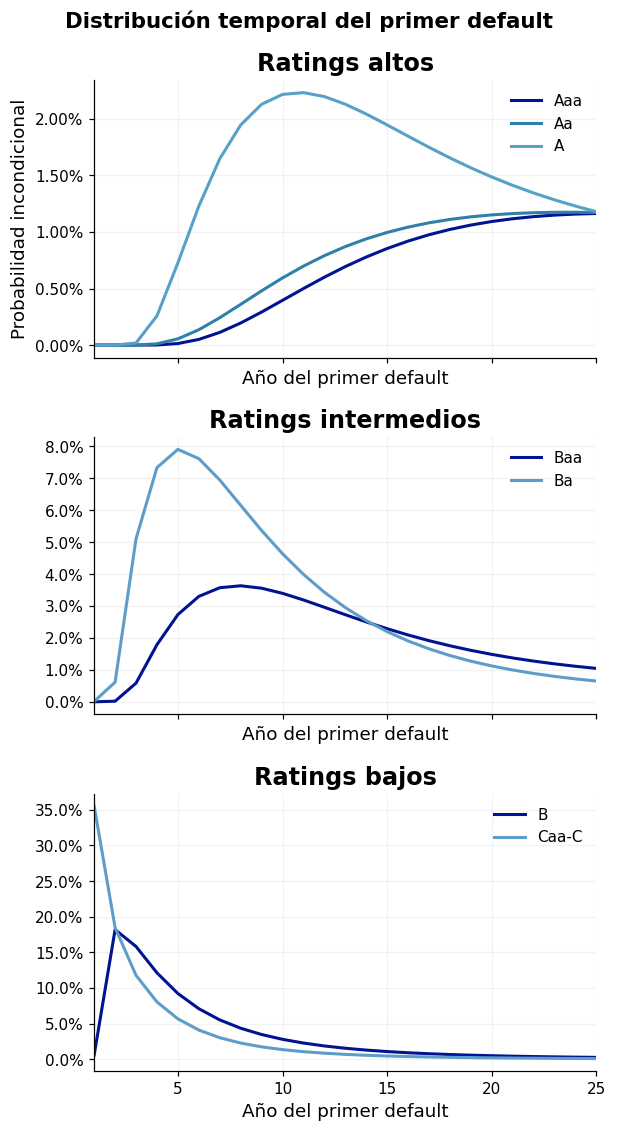

In [4]:
grupos = [
    ("Ratings altos", ["Aaa", "Aa", "A"]),
    ("Ratings intermedios", ["Baa", "Ba"]),
    ("Ratings bajos", ["B", "Caa-C"]),
]
colores = {
    "Aaa": "#001391", "Aa": "#2f80a8", "A": "#57a0c8",
    "Baa": "#001391", "Ba": "#5e9cc9",
    "B": "#001391", "Caa-C": "#5e9cc9",
}

fig, axes = plt.subplots(3, 1, figsize=(5.8, 10.5), sharex=True)
for ax, (titulo, nombres) in zip(axes, grupos):
    for nombre in nombres:
        i = RATINGS.index(nombre)
        ax.plot(anios, pd_exacta[i], lw=2,
                color=colores[nombre], label=nombre)
    ax.set(title=titulo, xlabel="Año del primer default", xlim=(1, 25))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend()
axes[0].set_ylabel("Probabilidad incondicional")
fig.suptitle("Distribución temporal del primer default",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


**Lectura de las formas.** En los ratings altos la masa de default tarda en acumularse y el máximo **observado** puede quedar en el último año representado; en ese caso solo sabemos que la curva sigue creciendo dentro de la ventana de 25 años, no que ese sea su máximo global. En los intermedios aparece una joroba en años centrales; en los bajos domina el riesgo inmediato y la curva cae con rapidez. No son tasas hazard condicionadas a supervivencia: son probabilidades incondicionales de primer default.


---

## Apartado 1.b — Cohorte de 5.002 compañías

### El puente de probabilidad individual a número de empresas

En 1.a cada cantidad estaba condicionada al rating inicial de **una empresa**. Ahora usamos la composición real de la cohorte.

Si hay $N_i$ compañías con rating inicial $i$ y

$$
p_i(n)=P(\tau=n\mid X_0=i),
$$

entonces el número esperado de defaults procedentes de ese rating durante el año $n$ es

$$
E[D_n^{(i)}]=N_i\,p_i(n).
$$

Sumando ratings,

$$
\boxed{E[D_n]=\sum_i N_i\,p_i(n).}
$$

No estamos creando una probabilidad nueva: estamos transformando probabilidades individuales en **conteos esperados** usando cuántas empresas hay en cada grupo.


¿Cuántas compañías esperamos que lleguen a Default? En 1.a calculamos probabilidades **condicionadas al rating inicial**; ahora las ponderamos por cuántas empresas tiene la cohorte en cada rating.

El enunciado proporciona el vector de **conteos**, en orden Aaa, Aa, A, Baa, Ba, B, Caa-C, Default:

$$N_0=(136,694,1298,1175,578,817,304,0),\qquad \sum_i N_{0,i}=5002.$$

Son 136 compañías inicialmente Aaa, 694 Aa, 1.298 A, etc.; la matriz $P$ describe cómo migran, no cuántas hay. El vector fila

$$N_n=N_0P^n$$

contiene los **números esperados** en cada estado al terminar el año $n$. Su componente $[N_n]_D$ cuenta los defaults esperados **acumulados** hasta ese año, porque Default es absorbente. En el primer año:

$$[N_0P]_D=\sum_i N_{0,i}P_{i,D}.$$

Cada rating aporta su número inicial de empresas multiplicado por su PD anual. La suma da **113,12 defaults esperados**, no un conteo observado: una esperanza puede ser fraccionaria, aunque cualquier realización tenga un número entero de empresas.

Para contar solo los primeros defaults **durante** el año $n$ restamos los acumulados:

$$d_n=[N_0P^n]_D-[N_0P^{n-1}]_D=\sum_i N_{0,i}\bigl[F_i(n)-F_i(n-1)\bigr].$$

Es la misma diferencia de 1.a aplicada a toda la cohorte. El código usa $p_0=N_0/5002$ y $p_n=p_0P^n$: sus componentes son **proporciones esperadas**; multiplicarlas por 5.002 recupera los conteos esperados. En particular, $d_n/5002$ es la proporción esperada de default exacto que muestra la tabla.

La suma de esperanzas no exige independencia entre compañías; esa hipótesis sería adicional si quisiéramos estudiar la dispersión del total.


In [5]:
CONTEOS = np.array([136, 694, 1298, 1175, 578, 817, 304, 0], dtype=float)
TOTAL = int(CONTEOS.sum())
assert TOTAL == 5_002
p0 = CONTEOS / TOTAL

cohorte_dist = np.array([p0 @ np.linalg.matrix_power(P, n) for n in anios])
cohorte_acum = cohorte_dist[:, -1]
cohorte_exacta = np.diff(np.r_[0.0, cohorte_acum])
cohorte_n = TOTAL * cohorte_exacta

assert np.allclose(cohorte_dist.sum(axis=1), 1.0, atol=2e-14)
assert np.all(cohorte_exacta >= -2e-15)
assert np.isclose(cohorte_exacta.sum(), cohorte_acum[-1])

tabla_cohorte = pd.DataFrame({
    "Proporción default exacto": cohorte_exacta,
    "Compañías esperadas": cohorte_n,
    "PD acumulada": cohorte_acum,
}, index=anios)
tabla_cohorte.index.name = "Año"

display(tabla_cohorte.style.format({
    "Proporción default exacto": "{:.4%}",
    "Compañías esperadas": "{:.2f}",
    "PD acumulada": "{:.4%}",
}))
print(f"Año modal del primer default: {1 + np.argmax(cohorte_exacta)}")
print(f"Defaults esperados hasta 25Y: {TOTAL*cohorte_acum[-1]:.2f} "
      f"({cohorte_acum[-1]:.4%} de la cohorte)")


,Proporción default exacto,Compañías esperadas,PD acumulada
Año,,,
1,2.2614%,113.12,2.2614%
2,4.1711%,208.64,6.4326%
3,4.0325%,201.70,10.4651%
4,3.8064%,190.40,14.2715%
5,3.6034%,180.24,17.8749%
6,3.4019%,170.16,21.2768%
7,3.1917%,159.65,24.4685%
8,2.9743%,148.78,27.4428%
9,2.7554%,137.83,30.1983%


Año modal del primer default: 2
Defaults esperados hasta 25Y: 2707.79 (54.1342% de la cohorte)


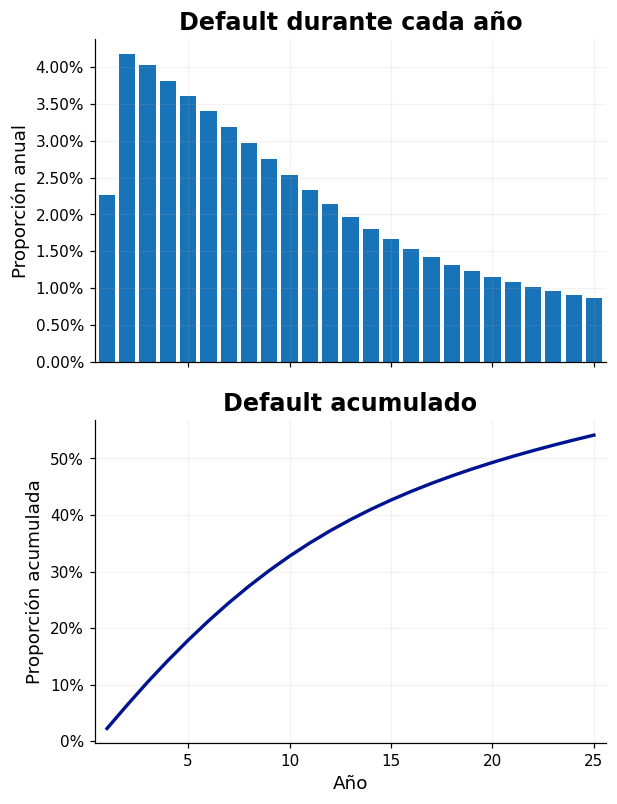

In [6]:
# Dos paneles: no mezclar probabilidades anuales y acumuladas en un doble eje.
fig, axes = plt.subplots(2, 1, figsize=(5.8, 7.5), sharex=True)
axes[0].bar(anios, cohorte_exacta, color="#1973b8", width=0.8)
axes[0].set(title="Default durante cada año", ylabel="Proporción anual")
axes[1].plot(anios, cohorte_acum, color="#001391", lw=2.2)
axes[1].set(title="Default acumulado", xlabel="Año", ylabel="Proporción acumulada")
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlim(0.4, 25.6)
fig.tight_layout()
plt.show()


**Lectura.** Arriba se cuentan los defaults nuevos de cada año; abajo se acumulan. La segunda curva debe crecer aunque la primera disminuya. Separar los ejes evita confundir ambas magnitudes.


### Control de la convención de entrada

El siguiente control verifica que todos los cálculos siguen usando la fila Caa como representante de Caa-C, sin introducir pesos de agregación.


In [7]:
# Control explícito de que la convención documentada es la que ejecuta el modelo.
assert np.array_equal(P[6], Q[ORIGENES.index("Caa")])
assert not np.array_equal(P[6], Q[ORIGENES.index("Ca-C")])
print("Convención Caa-C verificada: se usa la fila Caa y se descarta Ca-C.")


Convención Caa-C verificada: se usa la fila Caa y se descarta Ca-C.


### Simulación: una comprobación, no un método alternativo

La distribución exacta a 25 años ya está dada por $P^{25}$. La simulación reproduce muchas trayectorias de la cadena para comprobar que sus frecuencias empíricas convergen a esa distribución teórica. Primero resolvemos; después validamos.


---

## Apartado 1.c — Distribución de rating a 25 años

### Antes de calcular: aquí hay dos preguntas diferentes

Conviene separar dos objetos que se parecen algebraicamente pero responden a preguntas distintas.

**Si conozco el rating inicial $i$ de la empresa:**

$$
\boxed{e_iP^{25}}
$$

es su distribución de rating a 25 años condicionada a ese punto de partida.

**Si elijo una empresa al azar entre las 5.002 y no observo primero su rating:**

$$
\boxed{p_0P^{25}}
$$

mezcla las distribuciones anteriores usando como pesos las proporciones iniciales de la cohorte.

No son dos métodos para calcular lo mismo; son dos preguntas probabilísticas diferentes.


Elegimos una compañía **uniformemente entre las 5.002 de la cohorte**. Antes de observar su rating, $X_0$ es aleatorio; $X_n$ denota su estado al terminar el año $n$. La probabilidad inicial de cada rating es su proporción en la cohorte:

$$p_0=\frac{N_0}{5002},\qquad \Pr(X_0=A)=\frac{1298}{5002}.$$

Usamos $p_0$, la misma notación de 1.b (también suele escribirse $\pi_0$). Tras 25 transiciones, la ley de la empresa elegida al azar es:

$$\Pr(X_{25}=j)=[p_0P^{25}]_j=\sum_i p_{0,i}(P^{25})_{i,j}.$$

Esta distribución es **no condicionada al rating inicial**: mezcla todos los orígenes con sus pesos reales. Coincide con la proporción esperada de la cohorte en cada estado en 1.b.

El enunciado también pide estudiar «los distintos niveles de rating desde los que la compañía puede partir». Si conocemos $X_0=i$, la respuesta cambia a:

$$\Pr(X_{25}=j\mid X_0=i)=(P^{25})_{i,j}.$$

**Cada fila de $P^{25}$ es una distribución condicionada; $p_0P^{25}$ es una sola distribución que no observa el rating inicial.** Conservamos ambas respuestas.

### Cómo se simula una compañía

1. **Sin condicionar:** sortear $X_0\sim p_0$. **Condicionada:** fijar $X_0=i$.
2. Sortear $X_1$ con la fila de $P$ correspondiente a $X_0$; después $X_2$ con la fila de $X_1$, y así hasta $X_{25}$. Una vez en Default, permanece allí.
3. Repetir muchas trayectorias. Las frecuencias finales aproximan $p_0P^{25}$ en el primer caso y la fila $i$ de $P^{25}$ en el segundo. Son estimaciones Monte Carlo, no las probabilidades exactas.

**Qué ejecuta este notebook.** Simula 300.000 trayectorias **desde cada rating** y valida las siete filas. Después combina sus frecuencias con los pesos $p_0$: es la «Simulación ponderada» de la tabla final. Estima la misma distribución no condicionada que sortear $X_0\sim p_0$, pero no es una segunda simulación que sortee la empresa inicial ni tiene necesariamente el mismo error muestral.

En cada paso se guarda el estado anterior para que cada trayectoria haga exactamente una transición por año.


In [8]:
P25 = np.linalg.matrix_power(P, 25)
analitica_25 = P25[:7]
tabla_P25 = pd.DataFrame(analitica_25, index=RATINGS, columns=ESTADOS)

assert np.allclose(P25.sum(axis=1), 1.0, atol=3e-14)
assert np.all(P25 >= -2e-15)

print("Distribución analítica a 25 años — filas: rating inicial")
display(tabla_P25.style.format("{:.4%}"))


Distribución analítica a 25 años — filas: rating inicial


,Aaa,Aa,A,Baa,Ba,B,Caa-C,Default
Aaa,37.5273%,17.8215%,11.9252%,5.7768%,5.5144%,2.9272%,3.2274%,15.2802%
Aa,36.3420%,17.2849%,11.6103%,5.6414%,5.4332%,2.9075%,3.2355%,17.5452%
A,27.2730%,13.1386%,9.1075%,4.5350%,4.6774%,2.6540%,3.1458%,35.4688%
Baa,20.0082%,9.7333%,6.9067%,3.5003%,3.7822%,2.2268%,2.7384%,51.1040%
Ba,8.1363%,4.0673%,3.0722%,1.6281%,1.9602%,1.2478%,1.6472%,78.2409%
B,2.6676%,1.3566%,1.0639%,0.5783%,0.7368%,0.4870%,0.6635%,92.4464%
Caa-C,0.7695%,0.4004%,0.3291%,0.1843%,0.2498%,0.1714%,0.2406%,97.6548%


In [9]:
N_SIM = 300_000
rng = np.random.default_rng(20260902)
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0  # protege frente a redondeos en searchsorted

def simular_25_anios(estado_inicial):
    estados = np.full(N_SIM, estado_inicial, dtype=np.int8)
    for _ in range(25):
        anteriores = estados.copy()
        for estado in range(len(ESTADOS)):
            idx = np.flatnonzero(anteriores == estado)
            if idx.size:
                estados[idx] = np.searchsorted(
                    cdf[estado], rng.random(idx.size), side="right"
                )
    return np.bincount(estados, minlength=len(ESTADOS)) / N_SIM

simulada_25 = np.vstack([simular_25_anios(i) for i in range(7)])
error_25 = simulada_25 - analitica_25
se_25 = np.sqrt(np.maximum(
    analitica_25 * (1.0 - analitica_25) / N_SIM,
    1.0 / N_SIM**2,
))
z_25 = error_25 / se_25

# Gate estadístico celda a celda: error dentro de 4 SE, con holgura discreta.
tolerancia = 4.0 * se_25 + 5.0 / N_SIM
assert np.all(np.abs(error_25) <= tolerancia)

validacion = pd.DataFrame({
    "PD 25Y analítica": analitica_25[:, -1],
    "PD 25Y simulada": simulada_25[:, -1],
    "Error (pp)": 100 * error_25[:, -1],
}, index=RATINGS)
display(validacion.style.format({
    "PD 25Y analítica": "{:.4%}",
    "PD 25Y simulada": "{:.4%}",
    "Error (pp)": "{:+.4f}",
}))
print(f"Máximo error absoluto en las 56 celdas: {np.max(np.abs(error_25)):.6f}")
print(f"Máximo error estandarizado: {np.max(np.abs(z_25)):.2f} SE")

cohorte_25_analitica = p0 @ P25
cohorte_25_simulada = p0[:7] @ simulada_25
comparacion_cohorte = pd.DataFrame({
    "Analítica": cohorte_25_analitica,
    "Simulación ponderada": cohorte_25_simulada,
    "Error": cohorte_25_simulada - cohorte_25_analitica,
}, index=ESTADOS)
print("\nCompañía elegida al azar de la cohorte — distribución a 25 años:")
display(comparacion_cohorte.style.format("{:.4%}"))


,PD 25Y analítica,PD 25Y simulada,Error (pp)
Aaa,15.2802%,15.2990%,+0.0188
Aa,17.5452%,17.5450%,-0.0002
A,35.4688%,35.5270%,+0.0582
Baa,51.1040%,50.9987%,-0.1054
Ba,78.2409%,78.1350%,-0.1059
B,92.4464%,92.3980%,-0.0484
Caa-C,97.6548%,97.6837%,+0.0289


Máximo error absoluto en las 56 celdas: 0.001486
Máximo error estandarizado: 2.41 SE

Compañía elegida al azar de la cohorte — distribución a 25 años:


,Analítica,Simulación ponderada,Error
Aaa,19.2625%,19.2893%,0.0268%
Aa,9.2945%,9.2679%,-0.0266%
A,6.4697%,6.4897%,0.0200%
Baa,3.2326%,3.2164%,-0.0162%
Ba,3.3680%,3.3903%,0.0223%
B,1.9289%,1.9453%,0.0164%
Caa-C,2.3096%,2.2944%,-0.0152%
Default,54.1342%,54.1066%,-0.0276%


### Distribución y comprobación visual

El primer mapa muestra las siete distribuciones condicionadas: cada fila suma el 100 %. El segundo expresa la diferencia simulación − fórmula en errores estándar (SE). No es otra matriz de probabilidades: valores cercanos a cero indican concordancia. La tabla anterior conserva también la distribución de una compañía elegida al azar de la cohorte.


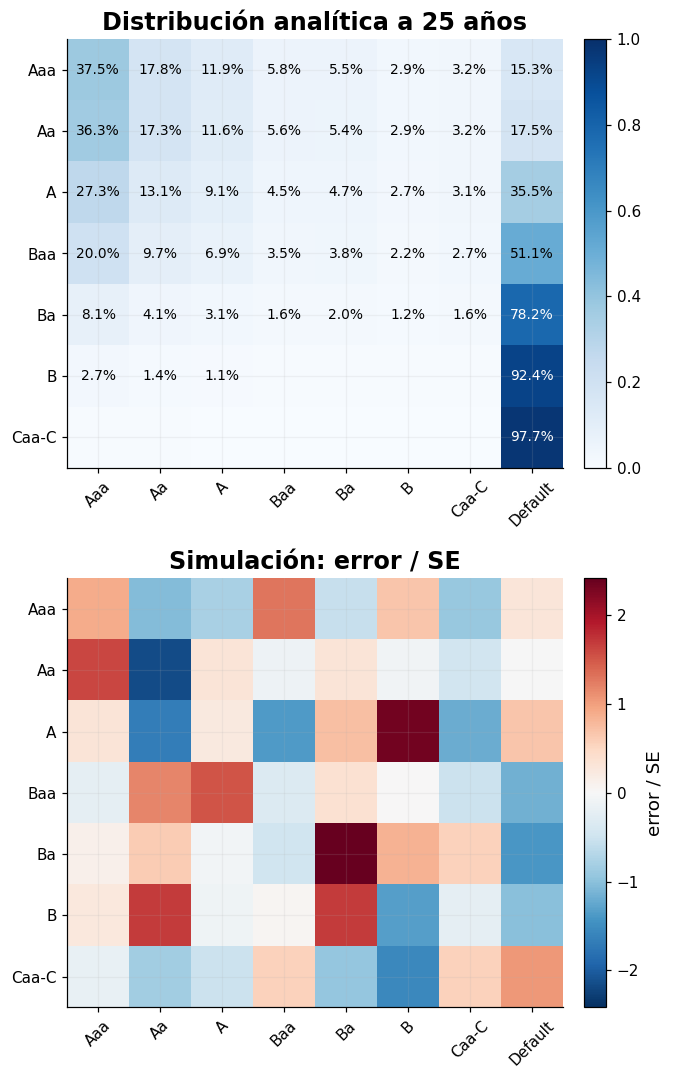

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(6.3, 10.0))

im0 = axes[0].imshow(analitica_25, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0].set(title="Distribución analítica a 25 años",
            xticks=range(8), xticklabels=ESTADOS,
            yticks=range(7), yticklabels=RATINGS)
axes[0].tick_params(axis="x", rotation=45)
for i in range(7):
    for j in range(8):
        if analitica_25[i, j] >= 0.01:
            axes[0].text(j, i, f"{analitica_25[i,j]:.1%}",
                         ha="center", va="center",
                         color="white" if analitica_25[i,j] > 0.55 else "black",
                         fontsize=9)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

vmax_z = np.max(np.abs(z_25))
im1 = axes[1].imshow(z_25, cmap="RdBu_r", vmin=-vmax_z, vmax=vmax_z, aspect="auto")
axes[1].set(title="Simulación: error / SE",
            xticks=range(8), xticklabels=ESTADOS,
            yticks=range(7), yticklabels=RATINGS)
axes[1].tick_params(axis="x", rotation=45)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="error / SE")

fig.tight_layout()
plt.show()


---

## Conclusiones

- La potencia de una matriz de transición da la distribución multi-periodo; la diferencia de PD acumuladas da la distribución del tiempo de primer default.
- Las curvas separan claramente los tres regímenes: riesgo tardío en ratings altos, joroba intermedia y fuerte masa inicial en ratings bajos.
- La simulación reproduce $P^{25}$ dentro del error Monte Carlo esperado.
- La matriz se cierra en ocho estados conservando la fila `Caa` como representante de `Caa-C`, de acuerdo con la convención permitida por la profesora.


In [11]:
print("=" * 78)
print("RESUMEN EJERCICIO 1 · MATRIZ 8×8 CORREGIDA")
print("=" * 78)
print(f"Cohorte — default exacto 1Y: {cohorte_exacta[0]:.4%} "
      f"({TOTAL*cohorte_exacta[0]:.2f} compañías esperadas)")
print(f"Cohorte — PD acumulada 25Y: {cohorte_acum[-1]:.4%} "
      f"({TOTAL*cohorte_acum[-1]:.2f} compañías esperadas)")
print("Convención Caa-C: fila Caa conservada; fila Ca-C eliminada")
print(f"Validación P^25 — máximo error: {np.max(np.abs(error_25)):.6f}; "
      f"máximo |z|: {np.max(np.abs(z_25)):.2f}")


RESUMEN EJERCICIO 1 · MATRIZ 8×8 CORREGIDA
Cohorte — default exacto 1Y: 2.2614% (113.12 compañías esperadas)
Cohorte — PD acumulada 25Y: 54.1342% (2707.79 compañías esperadas)
Convención Caa-C: fila Caa conservada; fila Ca-C eliminada
Validación P^25 — máximo error: 0.001486; máximo |z|: 2.41


## Cobertura del enunciado

Cada fila identifica las celdas de este notebook por su ID estable.

| Apartado del enunciado | Notebook / celdas que responden | Estado |
|---|---|---|
| 1.a · PD acumulada por rating, años 1–25 | Ejercicio 1: `bfe59764; 6ad27b3f` | PASS |
| 1.a · Primer default por año, gráfica y explicación por rating | Ejercicio 1: `6ad27b3f; 0b705372; 659c831b` | PASS |
| 1.b · Proporción anual de default de la cohorte de 5.002 compañías | Ejercicio 1: `48762b4d; 5ce5ccfc; 5b32b261` | PASS |
| 1.c · Distribución de todos los ratings a 25 años según estado inicial | Ejercicio 1: `c1fc6653; bdf0a249` | PASS |
| 1.c · Compañía aleatoria de la cohorte y comprobación por simulación | Ejercicio 1: `88a7ad97; b74c1768` | PASS |
| Dato original y convención de ocho estados | Ejercicio 1: `d570be1e; 5727c866; 0e2dbc24` | PASS |

Este notebook incluye los datos, las explicaciones, los cálculos y las figuras necesarios para su ejercicio. Puede ejecutarse desde un kernel limpio sin archivos auxiliares.